## Phase 4 - Model Comparison: Isolation Forest vs DBSCAN

**Goal:** Demonstrate why model selection matters in healthcare anomaly detection.

We test two unsupervised approaches on identical features and identical data.
The results will show that the right algorithm for a problem is determined
by the structure of the data - not by general reputation or popularity.

In [1]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import warnings
warnings.filterwarnings('ignore')

C:\Users\Manoj\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [2]:
# Load record
record = wfdb.rdrecord('100', pn_dir='mitdb')
annotation = wfdb.rdann('100', 'atr', pn_dir='mitdb')

ecg_signal = record.p_signal[:, 0]
fs = record.fs
ann_samples = annotation.sample
ann_symbols = annotation.symbol

# Rebuild features
rr_intervals = np.diff(ann_samples)
rr_ms = (rr_intervals / fs) * 1000
heart_rate = 60000 / rr_ms
rr_diff = np.append(0, np.diff(rr_ms))
rolling_mean_rr = pd.Series(rr_ms).rolling(window=5, min_periods=1).mean().values
rolling_std_rr = pd.Series(rr_ms).rolling(window=5, min_periods=1).std().fillna(0).values
relative_rr = rr_ms / rolling_mean_rr

feature_df = pd.DataFrame({
    'sample': ann_samples[1:],
    'symbol': ann_symbols[1:],
    'rr_interval': rr_ms,
    'heart_rate': heart_rate,
    'rr_diff': rr_diff,
    'rolling_mean_rr': rolling_mean_rr,
    'rolling_std_rr': rolling_std_rr,
    'relative_rr': relative_rr,
})

In [3]:
# Scale features
features = ['rr_interval', 'heart_rate', 'rr_diff', 'rolling_mean_rr', 'rolling_std_rr', 'relative_rr']

X = feature_df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Pipeline ready - {len(feature_df)} beats")

Pipeline ready - 2273 beats


#### Running Isolation Forest

In [4]:
# Isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.015,
    random_state=42
)
iso_forest.fit(X_scaled)
iso_predictions = iso_forest.predict(X_scaled)

feature_df['iso_flag'] = (iso_predictions == -1).astype(int)

In [5]:
# Evaluate
true_abnormal = feature_df[feature_df['symbol'] != 'N']
iso_caught = true_abnormal[true_abnormal['iso_flag'] == 1]
iso_false_pos = feature_df[
    (feature_df['iso_flag'] == 1) &
    (feature_df['symbol'] == 'N')
]

print("--- Isolation Forest ---")
print(f"Total flagged: {feature_df['iso_flag'].sum()}")
print(f"True anomalies caught: {len(iso_caught)}/{len(true_abnormal)}")
print(f"False positives: {len(iso_false_pos)}")
print(f"Detection rate: {len(iso_caught)/len(true_abnormal)*100:.1f}%")

--- Isolation Forest ---
Total flagged: 35
True anomalies caught: 18/34
False positives: 17
Detection rate: 52.9%


#### Now we run DBSCAN
We execute the DBSCAN in the default setting and this is an intentional approach as to see how it performs when the hyperparameters are kept untouched.

In [6]:
# DBSCAN - default epsilon
dbscan_default = DBSCAN(eps=0.5, min_samples=5)
dbscan_default_labels = dbscan_default.fit_predict(X_scaled)

# Verify labels were created
print(f"Unique labels from DBSCAN: {np.unique(dbscan_default_labels)}")
print(f"Number of anomalies (-1): {(dbscan_default_labels == -1).sum()}")

# Now assign
feature_df['dbscan_default_flag'] = (dbscan_default_labels == -1).astype(int)
true_abnormal = feature_df[feature_df['symbol'] != 'N']

# Confirm column exists
print(f"Columns now: {feature_df.columns.tolist()}")

# Evaluate
dbscan_d_caught = true_abnormal[true_abnormal['dbscan_default_flag'] == 1]
dbscan_d_false_pos = feature_df[
    (feature_df['dbscan_default_flag'] == 1) &
    (feature_df['symbol'] == 'N')
]

print("--- DBSCAN (default eps=0.5) ---")
print(f"Total flagged: {feature_df['dbscan_default_flag'].sum()}")
print(f"True anomalies caught: {len(dbscan_d_caught)}/{len(true_abnormal)}")
print(f"False positives: {len(dbscan_d_false_pos)}")
print(f"Detection rate: {len(dbscan_d_caught)/len(true_abnormal)*100:.1f}%")

Unique labels from DBSCAN: [-1  0  1  2  3  4  5  6]
Number of anomalies (-1): 195
Columns now: ['sample', 'symbol', 'rr_interval', 'heart_rate', 'rr_diff', 'rolling_mean_rr', 'rolling_std_rr', 'relative_rr', 'iso_flag', 'dbscan_default_flag']
--- DBSCAN (default eps=0.5) ---
Total flagged: 195
True anomalies caught: 24/34
False positives: 171
Detection rate: 70.6%


### Key learning
Without the tuning of model we can explicitly see that DBSCAN have flagged 195 as anomalies which is ~9% of data. From what we had seen 1.5% this difference is huge and it can be extremely dangerous in such scenarios

### We now tune DBSCAN

we use k-distance method to find the epsilon rather than the guess game

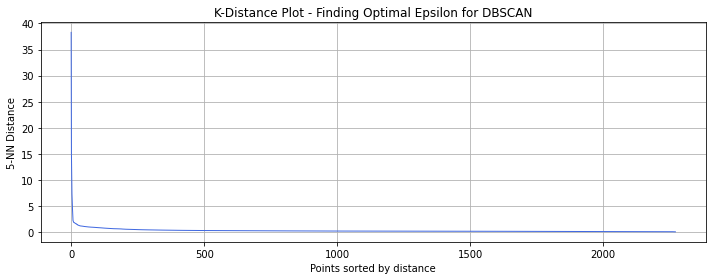

Look for the 'elbow' - the point where the curve bends sharply.
The y-value at the elbow is your optimal epsilon.


In [7]:
from sklearn.neighbors import NearestNeighbors

# K-distance plot - finds the natural epsilon for this data
k = 5  # same as min_samples
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)

# Sort distances to k-th nearest neighbour
k_distances = np.sort(distances[:, k-1])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(k_distances, color='royalblue', linewidth=1)
plt.title('K-Distance Plot - Finding Optimal Epsilon for DBSCAN')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{k}-NN Distance')
plt.grid(True)
plt.tight_layout()
plt.show()

print("Look for the 'elbow' - the point where the curve bends sharply.")
print("The y-value at the elbow is your optimal epsilon.")

### Key takeaway
The k-distance plot sorts every point by how far it is from its 5th nearest neighbour. The elbow - where the curve bends sharply from flat to steep - marks the boundary between dense normal region and sparse anomaly region. The y-value at that elbow is the right epsilon.

In [8]:
# Replacing this value with what was seen at the elbow
optimal_eps = 0.85

dbscan_tuned = DBSCAN(eps=optimal_eps, min_samples=5)
dbscan_tuned_labels = dbscan_tuned.fit_predict(X_scaled)

feature_df['dbscan_tuned_flag'] = (dbscan_tuned_labels == -1).astype(int)
true_abnormal = feature_df[feature_df['symbol'] != 'N']

# Evaluate
dbscan_t_caught = true_abnormal[true_abnormal['dbscan_tuned_flag'] == 1]
dbscan_t_false_pos = feature_df[
    (feature_df['dbscan_tuned_flag'] == 1) &
    (feature_df['symbol'] == 'N')
]

print("--- DBSCAN (tuned epsilon) ---")
print(f"Epsilon used: {optimal_eps}")
print(f"Total flagged: {feature_df['dbscan_tuned_flag'].sum()}")
print(f"True anomalies caught: {len(dbscan_t_caught)}/{len(true_abnormal)}")
print(f"False positives: {len(dbscan_t_false_pos)}")
print(f"Detection rate: {len(dbscan_t_caught)/len(true_abnormal)*100:.1f}%")

--- DBSCAN (tuned epsilon) ---
Epsilon used: 0.85
Total flagged: 70
True anomalies caught: 6/34
False positives: 64
Detection rate: 17.6%


In [9]:
print("--- FINAL MODEL COMPARISON ---")
print(f"{'Model':<30} {'Flagged':>8} {'Caught':>8} "
      f"{'False+':>8} {'Rate':>8}")
print("-" * 65)
print(f"{'Isolation Forest':<30} "
      f"{feature_df['iso_flag'].sum():>8} "
      f"{len(iso_caught):>8} "
      f"{len(iso_false_pos):>8} "
      f"{len(iso_caught)/len(true_abnormal)*100:>7.1f}%")
print(f"{'DBSCAN (default eps=0.5)':<30} "
      f"{feature_df['dbscan_default_flag'].sum():>8} "
      f"{len(dbscan_d_caught):>8} "
      f"{len(dbscan_d_false_pos):>8} "
      f"{len(dbscan_d_caught)/len(true_abnormal)*100:>7.1f}%")
print(f"{'DBSCAN (tuned)':<30} "
      f"{feature_df['dbscan_tuned_flag'].sum():>8} "
      f"{len(dbscan_t_caught):>8} "
      f"{len(dbscan_t_false_pos):>8} "
      f"{len(dbscan_t_caught)/len(true_abnormal)*100:>7.1f}%")

--- FINAL MODEL COMPARISON ---
Model                           Flagged   Caught   False+     Rate
-----------------------------------------------------------------
Isolation Forest                     35       18       17    52.9%
DBSCAN (default eps=0.5)            195       24      171    70.6%
DBSCAN (tuned)                       70        6       64    17.6%


### Reading the Results - Three Stories

**Isolation Forest: 52.9% detection, 17 false positives**
Controlled, calibrated, clinically trustworthy. 35 alarms - 18 real.
The contamination parameter anchors the model to what we know from the data.

**DBSCAN default (eps=0.5): 70.6% detection, 171 false positives**
Highest raw detection rate - but 87.7% of alarms are false.
In a clinical setting this model would be ignored within hours.
High recall with catastrophic precision is more dangerous than lower recall.

**DBSCAN tuned (eps=0.85): 17.6% detection, 64 false positives**
Over-corrected. A 0.35 change in epsilon collapsed detection by 53 points.
This is DBSCAN's fundamental weakness on imbalanced data - the dense 
normal cluster dominates neighbourhood calculations. Any epsilon large 
enough to properly cluster normals absorbs most anomalies too.

**Conclusion:**
DBSCAN is not wrong as an algorithm - it is wrong for this problem.
Unsupervised anomaly detection on heavily imbalanced cardiac data requires 
an algorithm designed for that specific challenge. Isolation Forest is.
Model selection is not about which algorithm is best in general.
It is about which algorithm fits the structure of your specific problem.

**To summarize this phase** 
- we took DBSCAN and implemented two versions of it. Defalut and the tuned.
- The results have been discussed in the above cell and drawn to the conclusion that Isolation Forest is our best choice given we tried fine-tuning the model using the elbow curve, picking the right epsilon and multiple variations in the decimal point of epsilon only to conclude they underperform in these type of data.

`Next step would be to simulate IoT`